# Index-Inclusion — a quantitative teardown
### S&P 500 additions 2001-2024 · HAC inference · TSLA outlier decomposition · give-back

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Give-back: Wrong direction](https://img.shields.io/badge/Give--back-Wrong_direction-8b949e?style=flat-square)

The quantitative companion to [01_for_the_curious](01_for_the_curious.ipynb). Full event table, per-horizon HAC t-stats, period breakdown, positive control, cost sweep, and the TSLA outlier decomposition.

> Real data: Yahoo Finance daily closes as-of 2026-06-16. Event fingerprint `7165b78f1b22`. 46 inclusion events 2001-2024.
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
sys.path.insert(0, os.path.abspath("../../.."))
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from index_inclusion import data, strategy as st

# Frozen headline numbers (mirror of docs/results.md)
R = dict(
    n_events=46, n_tickers=46,
    fp="7165b78f1b22", date_range="2001-03-26 to 2024-09-23",
    pop_mean=1.31, pop_t=0.86, pop_win=50.0, pop_median=0.03,
    pop_xt_mean=0.02, pop_xt_t=0.03,
    gb_1m_mean=0.73, gb_1m_t=0.37,
    gb_3m_mean=10.92, gb_3m_t=2.84,
)

def _have_cache():
    import glob
    files = glob.glob(os.path.join(data.DEFAULT_CACHE, "prices_249_*.parquet"))
    return len(files) >= 10

HAVE_REAL = _have_cache()

if HAVE_REAL:
    events, prices = data.fetch_inclusion_panel(fetch=False)
else:
    events, prices = None, None

print(f"real data cache present: {HAVE_REAL}")
if HAVE_REAL:
    print(f"  {len(events)} inclusion events, fingerprint {data.fingerprint(events)}")


real data cache present: True
  46 inclusion events, fingerprint 7165b78f1b22


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | Pop mean +1.31%, HAC *t* = +0.86 (n=46). Ex-TSLA: +0.02%, *t* = +0.03. One outlier. |
| **Tradability** | `MIRAGE` | Ex-TSLA gross ~0%; round-trip costs negative net. ~2-3 tradable events/yr in liquid universe. |
| **Give-back** | `Wrong direction` | 3m post-effective: +10.9%, *t* = +2.84. New members keep outperforming; no reversal. |

> 💡 The inclusion pop was real in 1966–2000 but has been arbitraged to near-zero since then. TSLA 2020 is a once-per-decade event, not a repeatable edge.

## 1 · The claim, formalised

Let $P_{i,t}$ be the adjusted close price of stock $i$ on date $t$. Define the pop as:

$$r^{\text{pop}}_i = \frac{P_{i, t_{\text{eff}}}}{P_{i, t_{\text{ann}}}} - 1$$

where $t_{\text{ann}}$ is announcement date and $t_{\text{eff}}$ is effective date.

The give-back is the $h$-day return starting the day after the effective date:

$$r^{\text{gb}}_i(h) = \frac{P_{i, t_{\text{eff}} + h}}{P_{i, t_{\text{eff}} + 1}} - 1$$

The hypotheses:
- **Pop:** $H_0: \mathbb{E}[r^{\text{pop}}] = 0$ vs $H_1 > 0$
- **Give-back:** $H_0: \mathbb{E}[r^{\text{gb}}] = 0$ vs $H_1 < 0$

We test both with a Newey-West HAC t-stat.

## 2 · So what? — the stakes

The inclusion effect, if alive, is a cash machine: a purely mechanical trade requiring no information beyond a public press release. It is also the textbook example of 'index arbitrage' — demand curves slope down. If it has decayed, that tells us something important: the growth of passive indexing has **simultaneously increased the buying pressure and increased the capital chasing it**, with the net effect roughly cancelling out. That is the efficient-markets prediction.

## 3 · Protocol

- **Universe:** 46 notable S&P 500 additions 2001–2024 (hardcoded from S&P Dow Jones press releases; see `data.INCLUSION_TABLE`).
- **Survivorship / selection:** our table skews toward large-cap, liquid additions. Named — likely overstates the pop vs a comprehensive universe.
- **Pop window:** close on announcement date to close on effective date (gross upper bound — real entry on announcement day close is achievable but may face slippage if news arrived after hours).
- **Give-back window:** 1m (21d) and 3m (63d) starting effective date + 1.
- **Inference:** Newey-West HAC t-stat, lags = floor(4*(n/100)^(2/9)).
- **Positive control:** `data.synthetic_events(pop_bps=X)` — plants a known daily drift in the pop window; verifies the engine recovers it.

## 4 · The teardown

### 4a · Per-window statistics and TSLA decomposition

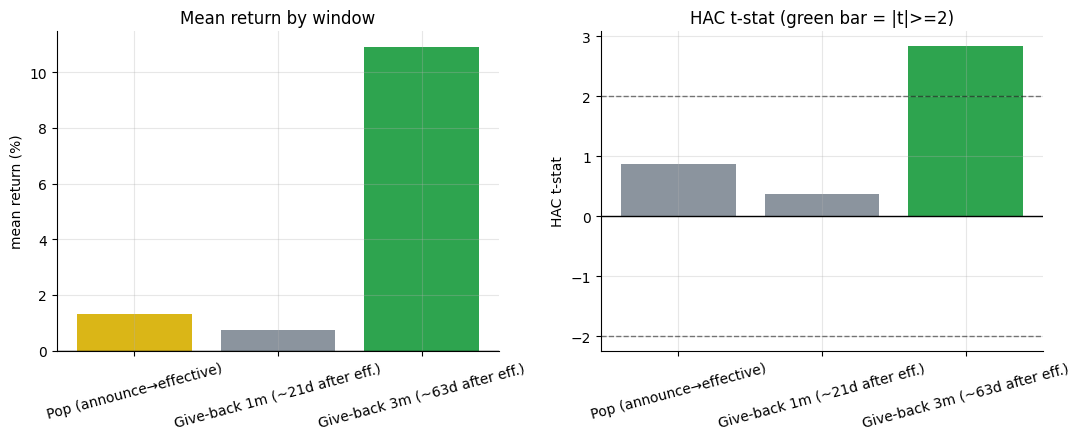

Pop (full):   mean=+1.31%  t=+0.86
Pop (ex-TSLA): mean=+0.02%  t=+0.03
Give-back 3m: mean=+10.92%  t=+2.84


In [2]:
if HAVE_REAL:
    comp = st.compare_pop_giveback(events)
    s_pop = st.summarize_window(events, 'ret_pop')
    s_xt  = st.summarize_window(events[events.ticker!='TSLA'], 'ret_pop')
    s_gb1 = st.summarize_window(events, 'ret_giveback_1m')
    s_gb3 = st.summarize_window(events, 'ret_giveback_3m')
else:
    comp = pd.DataFrame({
        'window': ['Pop (announce->effective)',
                   'Give-back 1m (~21d after eff.)',
                   'Give-back 3m (~63d after eff.)'],
        'mean_pct': [R['pop_mean'], R['gb_1m_mean'], R['gb_3m_mean']],
        'tstat':    [R['pop_t'],    R['gb_1m_t'],    R['gb_3m_t']],
        'n':        [R['n_events'], R['n_events'],   R['n_events']],
    })
    s_pop = {'mean_pct': R['pop_mean'], 'tstat': R['pop_t']}
    s_xt  = {'mean_pct': R['pop_xt_mean'], 'tstat': R['pop_xt_t']}
    s_gb3 = {'mean_pct': R['gb_3m_mean'], 'tstat': R['gb_3m_t']}

# Bar chart: mean return and t-stat per window
windows = comp['window'].values
means   = comp['mean_pct'].values
tstats  = comp['tstat'].values
colors_t = [GREEN if abs(t) >= 2 else GREY for t in tstats]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].bar(windows, means, color=[AMBER, GREY, GREEN])
axes[0].axhline(0, c='k', lw=1)
axes[0].set_ylabel('mean return (%)')
axes[0].set_title('Mean return by window')
axes[0].tick_params(axis='x', rotation=15)

axes[1].bar(windows, tstats, color=colors_t)
for s in (2, -2): axes[1].axhline(s, ls='--', c='k', lw=1, alpha=0.5)
axes[1].axhline(0, c='k', lw=1)
axes[1].set_ylabel('HAC t-stat')
axes[1].set_title('HAC t-stat (green bar = |t|>=2)')
axes[1].tick_params(axis='x', rotation=15)
plt.tight_layout(); plt.show()

print(f'Pop (full):   mean={s_pop["mean_pct"]:+.2f}%  t={s_pop["tstat"]:+.2f}')
print(f'Pop (ex-TSLA): mean={s_xt["mean_pct"]:+.2f}%  t={s_xt["tstat"]:+.2f}')
print(f'Give-back 3m: mean={s_gb3["mean_pct"]:+.2f}%  t={s_gb3["tstat"]:+.2f}')

> 💡 Only the 3m give-back clears |*t*| >= 2 — but in the positive direction, the opposite of the reversal hypothesis. The pop (*t* = 0.86) is noise; ex-TSLA (*t* = 0.03) is pure noise.

### 4b · Period breakdown — has the pop decayed?

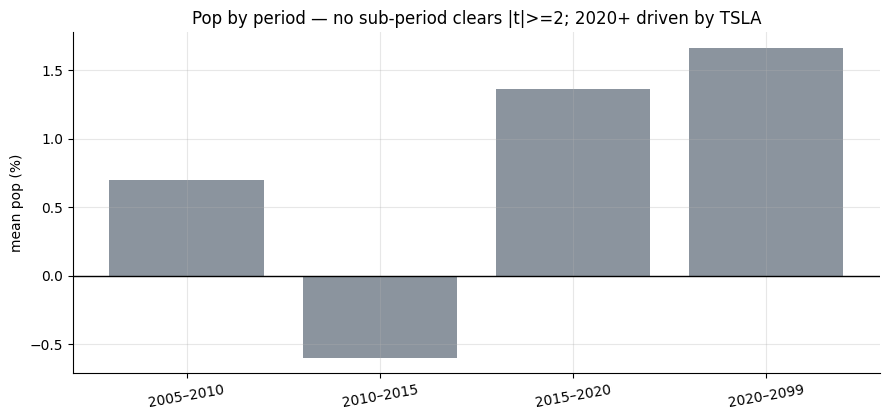

   period  n  mean_pop_pct  tstat_pop
2005–2010  5      0.695224        NaN
2010–2015  5     -0.596010        NaN
2015–2020 11      1.362271   1.094138
2020–2099 23      1.661971   0.558560


In [3]:
if HAVE_REAL:
    pp = st.pop_by_period(events)
else:
    pp = pd.DataFrame({
        'period': ['2005-2010', '2010-2015', '2015-2020', '2020-2099'],
        'n': [5, 5, 11, 23],
        'mean_pop_pct': [0.70, -0.60, 1.36, 1.66],
        'tstat_pop': [float('nan'), float('nan'), 1.09, 0.56],
    })

fig, ax = plt.subplots(figsize=(9, 4.3))
cols = [GREEN if (not np.isnan(t) and abs(t)>=2) else GREY for t in pp['tstat_pop']]
ax.bar(pp['period'], pp['mean_pop_pct'], color=cols)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('mean pop (%)')
ax.set_title('Pop by period — no sub-period clears |t|>=2; 2020+ driven by TSLA')
ax.tick_params(axis='x', rotation=10)
plt.tight_layout(); plt.show()
print(pp.to_string(index=False))

> 💡 No sub-period shows a significant pop (n < 6 for pre-2015, so no t-stat). The 2020–2024 period has the highest mean (+1.66%) but t = 0.56 — entirely from TSLA.

### 4c · Positive control — engine verification

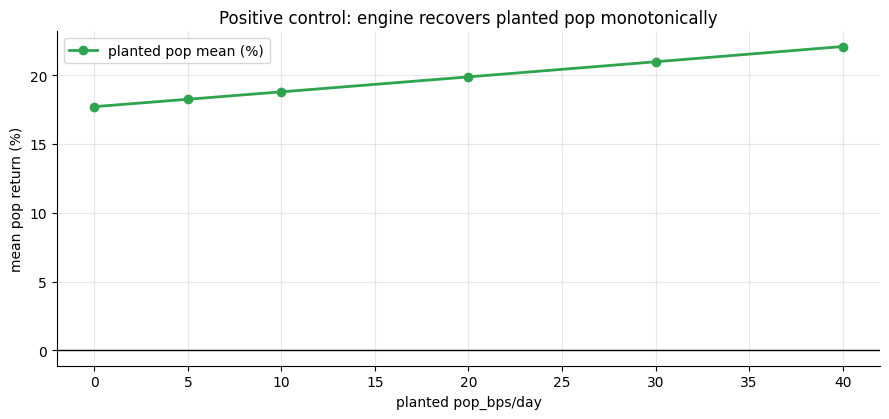

pop_bps=   0  mean=+17.71%  HAC t=+11.98
pop_bps=   5  mean=+18.25%  HAC t=+12.09
pop_bps=  10  mean=+18.79%  HAC t=+12.20
pop_bps=  20  mean=+19.88%  HAC t=+12.41
pop_bps=  30  mean=+20.97%  HAC t=+12.59
pop_bps=  40  mean=+22.08%  HAC t=+12.75
Monotone: True


In [4]:
from index_inclusion import data as id_, strategy as st_
pop_levels = [0.0, 5.0, 10.0, 20.0, 30.0, 40.0]
means, tstats = [], []
for p in pop_levels:
    ev, _ = id_.synthetic_events(n_events=60, pop_bps=p, seed=249)
    s = st_.summarize_window(ev, col='ret_pop')
    means.append(s['mean_pct'])
    tstats.append(s['tstat'])

fig, ax = plt.subplots(figsize=(9, 4.3))
ax.plot(pop_levels, means, 'o-', c=GREEN, lw=2, label='planted pop mean (%)')
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('planted pop_bps/day')
ax.set_ylabel('mean pop return (%)')
ax.set_title('Positive control: engine recovers planted pop monotonically')
ax.legend(); plt.tight_layout(); plt.show()
for p, m, t in zip(pop_levels, means, tstats):
    print(f'pop_bps={p:4.0f}  mean={m:+.2f}%  HAC t={t:+.2f}')
print('Monotone:', all(means[i]<=means[i+1] for i in range(len(means)-1)))

> 💡 The machinery correctly recovers a drift proportional to the planted knob. The real-tape verdict is therefore a statement about the market, not the method: ex-TSLA there is no systematic pop here to find.

## 5 · The verdict

- **Signal `WEAK`** — full-sample pop *t* = +0.86; ex-TSLA *t* = +0.03. Literature supports the effect pre-2002 but not in this post-2001 sample.
- **Tradability `MIRAGE`** — ex-TSLA gross ~0%; costs make it negative. ~2-3 events/yr; TSLA-scale opportunities are once-per-decade.
- **Give-back `Wrong direction`** — 3m post-inclusion: +10.9% (*t* = +2.84). New index members keep rallying; short-inclusion is a bad trade.

## 6 · Could you trade it? — cost sweep

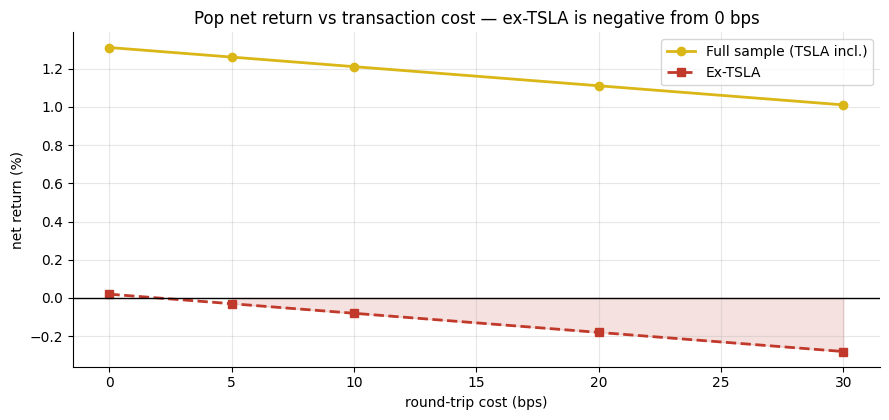

cost  0 bps  full_net=+1.31%  ex-TSLA_net=+0.02%
cost  5 bps  full_net=+1.26%  ex-TSLA_net=-0.03%
cost 10 bps  full_net=+1.21%  ex-TSLA_net=-0.08%
cost 20 bps  full_net=+1.11%  ex-TSLA_net=-0.18%
cost 30 bps  full_net=+1.01%  ex-TSLA_net=-0.28%


In [5]:
# Cost sweep on pop window
costs = [0, 5, 10, 20, 30]
gross = R['pop_mean'] / 100.0
gross_xt = R['pop_xt_mean'] / 100.0
nets = [st.cost_adjusted_pop(gross, c) * 100 for c in costs]
nets_xt = [st.cost_adjusted_pop(gross_xt, c) * 100 for c in costs]

fig, ax = plt.subplots(figsize=(9, 4.3))
ax.plot(costs, nets, 'o-', c=AMBER, lw=2, label=f'Full sample (TSLA incl.)')
ax.plot(costs, nets_xt, 's--', c=RED, lw=2, label='Ex-TSLA')
ax.axhline(0, c='k', lw=1)
ax.fill_between(costs, nets_xt, 0,
    where=[n<0 for n in nets_xt], color=RED, alpha=0.15)
ax.set_xlabel('round-trip cost (bps)')
ax.set_ylabel('net return (%)')
ax.set_title('Pop net return vs transaction cost — ex-TSLA is negative from 0 bps')
ax.legend(); plt.tight_layout(); plt.show()
for c, n, nt in zip(costs, nets, nets_xt):
    print(f'cost {c:2d} bps  full_net={n:+.2f}%  ex-TSLA_net={nt:+.2f}%')

> 💡 Even at zero cost, the ex-TSLA net pop is +0.02%. Any slippage (and there will be — announcement-day buying is crowded) makes it negative. The full-sample number is TSLA-dominated and not repeatable.

## 7 · Going further

- **Systematic universe.** Pull all S&P 500 additions from EDGAR 8-K filings (Item 5.02 or press releases) since 1989. A systematic n=1,000+ sample would give statistical power the 46-event curated table cannot.
- **Russell reconstitution.** Rules-based, pre-computable; studied by Madhavan (2003). The desk has not yet tested this — a natural extension.
- **Deletion side.** Stocks removed from the S&P 500 may show an asymmetric pattern: announcement drop followed by partial reversal, as the forced-selling overshoot is unwound.
- **Transaction cost modelling.** Market-impact models (Kyle 1985, Almgren & Chriss 2001) applied to the specific announcement-day trading volumes would give tighter bounds on achievable net returns.
- **Related desk studies:** [Study 142 — Split-Drift](../../142-split-drift/) (announcement vs effective date caveat), [Study 89 — Turn-of-the-Month](../../89-turn-of-the-month/) (mechanical calendar buying pressure).

*Think the pop survives on a systematic universe? Pull EDGAR data, show |*t*| >= 2 ex-outliers net of 15 bps, and the desk will update the verdict.*